In [1]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

/Users/juanjo/UPC/PD/Lab/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/comp.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


INFO:tensorflow:Restoring parameters from /Users/juanjo/UPC/PD/Lab/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_GAP/model
INFO:tensorflow:Restoring parameters from /Users/juanjo/UPC/PD/Lab/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_STRAIGHT/model
INFO:tensorflow:Restoring parameters from /Users/juanjo/UPC/PD/Lab/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_BENT_RAND/model


In [ ]:
# 3 add muxes and 3 drop filters


netlist = {
    "instances": {
        "ring_m1_up": "half_ring",
        "ring_m1_down": "half_ring",
        "ring_m2_up": "half_ring",
        "ring_m2_down": "half_ring",
        # "ring_m3_up": "half_ring",
        # "ring_m3_down": "half_ring",
        "ring_d1_up": "half_ring",
        "ring_d1_down": "half_ring",
        "ring_d2_up": "half_ring",
        "ring_d2_down": "half_ring",
        # "ring_d3_up": "half_ring",
        # "ring_d3_down": "half_ring",
        "wg1": "waveguide",
        "wg2": "waveguide",
        "wg3": "waveguide",
    },
    "connections": {
        "ring_m1_up,o1": "ring_m1_down,o3",
        "ring_m1_down,o1": "ring_m1_up,o3",
        "ring_m2_up,o1": "ring_m2_down,o3",
        "ring_m2_down,o1": "ring_m2_up,o3",
        # "ring_m3_up,o1": "ring_m3_down,o3",
        # "ring_m3_down,o1": "ring_m3_up,o3",
        "ring_d1_up,o1": "ring_d1_down,o3",
        "ring_d1_down,o1": "ring_d1_up,o3",
        "ring_d2_up,o1": "ring_d2_down,o3",
        "ring_d2_down,o1": "ring_d2_up,o3",
        # "ring_d3_up,o1": "ring_d3_down,o3",
        # "ring_d3_down,o1": "ring_d3_up,o3",
        "wg1,o0": "ring_m1_up,o2",
        "wg1,o1": "ring_m2_up,o0",
        "wg2,o0": "ring_m2_up,o2",
        "wg2,o1": "ring_d1_up,o0",
        "wg3,o0": "ring_d1_up,o2",
        "wg3,o1": "ring_d2_up,o0",
    },
    "ports": {
        "laser_in": "ring_m1_up,o0",
        "out_1": "ring_d1_down,o2", # drop port of drop filter 1
        "out_2": "ring_d2_down,o2", # drop port of drop filter 2
        "out_remaining": "ring_d2_up,o2", # through port of drop filter 2
    }
}

models = {
    "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    "waveguide": siepic.waveguide,
}

params = {
    "ring_m1_up": {"radius": 5},
    "ring_m1_down": {"radius": 5},
    "ring_m2_up": {"radius": 7},
    "ring_m2_down": {"radius": 7},
    # "ring_m3_up": {"radius": 9},
    # "ring_m3_down": {"radius": 9},
    "ring_d1_up": {"radius": 5},
    "ring_d1_down": {"radius": 5},
    "ring_d2_up": {"radius": 7},
    "ring_d2_down": {"radius": 7},
    # "ring_d3_up": {"r": 9},
    # "ring_d3_down": {"r": 9},
    "wg1": {"length": 10},
    "wg2": {"length": 30},
    "wg3": {"length": 10},
}

# create the circuit
circuit, info = sax.circuit(
    netlist=netlist,
    models=models
)

In [ ]:
wls = np.linspace(1.55, 1.6, 100)
S = circuit(wl=wls, **params)

In [ ]:
# Power
mag = jnp.abs(S["out_1","laser_in"])**2
# Loss
loss = 10*jnp.log10(mag)
# Phase
phase = jnp.angle(S["out_1","laser_in"])

In [ ]:
# Plot Power
plt.figure()
plt.plot(wls, mag)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port 1")

In [ ]:
mag_2 = jnp.abs(S["out_2","laser_in"])**2
plt.figure()
plt.plot(wls, mag_2)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port 2")
plt.grid()

In [ ]:
# remaining power at through port
mag_remaining = jnp.abs(S["out_remaining","laser_in"])**2
plt.figure()
plt.plot(wls, mag_remaining)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Through Port")
plt.grid()

## Test Varying Radius WDM Hypothesis

In [105]:
# 3 add muxes and 3 drop filters
netlist = {
    "instances": {
        "ring_m1_up": "half_ring",
        "ring_m1_down": "half_ring",
        "ring_a1_up": "half_ring",
        "ring_a1_down": "half_ring",
        "ring_m2_up": "half_ring",
        "ring_m2_down": "half_ring",
        "ring_a2_up": "half_ring",
        "ring_a2_down": "half_ring",
        # "ring_m3_up": "half_ring",
        # "ring_m3_down": "half_ring",
        # "ring_d1_up": "half_ring",
        # "ring_d1_down": "half_ring",
        # "ring_d2_up": "half_ring",
        # "ring_d2_down": "half_ring",
        # "ring_d3_up": "half_ring",
        # "ring_d3_down": "half_ring",
        "wg1": "waveguide",
        "wg2": "waveguide",
        "wg3": "waveguide",
    },
    "connections": {
        "ring_m1_up,o1": "ring_m1_down,o3",
        "ring_m1_down,o1": "ring_m1_up,o3",
        "ring_a1_up,o1": "ring_a1_down,o3",
        "ring_a1_down,o1": "ring_a1_up,o3",
        
        "ring_m1_down,o2": "wg1,o0",
        "ring_a1_up,o2": "wg1,o1",

        "ring_m2_up,o1": "ring_m2_down,o3",
        "ring_m2_down,o1": "ring_m2_up,o3",
        "ring_a2_up,o1": "ring_a2_down,o3",
        "ring_a2_down,o1": "ring_a2_up,o3",
        
        "ring_m2_down,o2": "wg2,o0",
        "ring_a2_up,o2": "wg2,o1",
        
        "ring_a1_down,o0": "wg3,o0",
        "ring_a2_down,o2": "wg3,o1",
        # "ring_m3_up,o1": "ring_m3_down,o3",
        # "ring_m3_down,o1": "ring_m3_up,o3",
        # "ring_d1_up,o1": "ring_d1_down,o3",
        # "ring_d1_down,o1": "ring_d1_up,o3",
        # "ring_d2_up,o1": "ring_d2_down,o3",
        # "ring_d2_down,o1": "ring_d2_up,o3",
        # "ring_d3_up,o1": "ring_d3_down,o3",
        # "ring_d3_down,o1": "ring_d3_up,o3",
        # "wg1,o0": "ring_m1_up,o2",
        # "wg1,o1": "ring_m2_up,o0",
        # "wg2,o0": "ring_m2_up,o2",
        # "wg2,o1": "ring_d1_up,o0",
        # "wg3,o0": "ring_d1_up,o2",
        # "wg3,o1": "ring_d2_up,o0",
        # "ring_m1_down,o2": "ring_a1_up,o2",
    },
    "ports": {
        "laser_in1": "ring_m1_up,o0",
        "laser_in2": "ring_m2_up,o0",
        "bus": "ring_a2_down,o0", # drop port of drop filter 1
    }
}

models = {
    "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    "waveguide": siepic.waveguide,
}

params = {
    "ring_m1_up": {"radius": 5},
    "ring_m1_down": {"radius": 5},
    "ring_a1_up": {"radius": 5},
    "ring_a1_down": {"radius": 5},
    "ring_m2_up": {"radius": 8},
    "ring_m2_down": {"radius": 8},
    "ring_a2_up": {"radius": 8},
    "ring_a2_down": {"radius": 8},
    "wg1": {"length": 10},
    "wg2": {"length": 10},
    "wg3": {"length": 20},
    # "ring_m2_up": {"radius": 7},
    # "ring_m2_down": {"radius": 7},
    # "ring_m3_up": {"radius": 9},
    # "ring_m3_down": {"radius": 9},
    # "ring_d1_up": {"radius": 5},
    # "ring_d1_down": {"radius": 5},
    # "ring_d2_up": {"radius": 7},
    # "ring_d2_down": {"radius": 7},
    # "ring_d3_up": {"r": 9},
    # "ring_d3_down": {"r": 9},
    # "wg1": {"length": 10},
    # "wg2": {"length": 30},
    # "wg3": {"length": 10},
}

# create the circuit
circuit, info = sax.circuit(
    netlist=netlist,
    models=models
)



In [106]:
%matplotlib widget


FloatSlider(value=5.0, description='r1 (um):', max=5.5, min=4.5, step=0.05)

FloatSlider(value=8.0, description='r2 (um):', max=8.5, min=7.5, step=0.05)

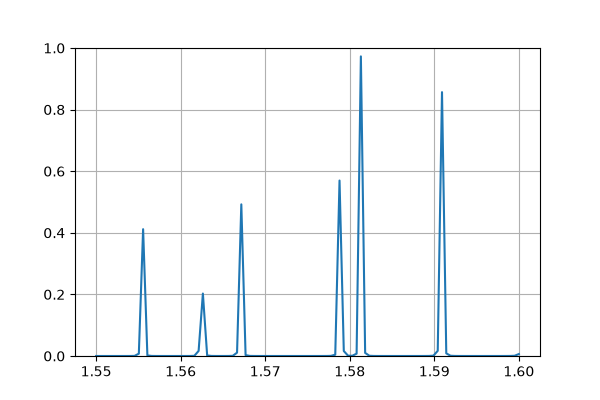

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

out = widgets.Output()

wls = np.linspace(1.55, 1.6, 100)
x = wls
S = circuit(wl=wls, **params)
power_bus = jnp.abs(S["bus","laser_in1"])**2 + jnp.abs(S["bus","laser_in2"])**2

fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot(wls, power_bus)

# ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)
ax.grid(True)

slider = widgets.FloatSlider(
    value=5.0,
    min=4.5,
    max=5.5,
    step=0.05,
    description="r1 (um):",
    continuous_update=True
)

slider_r2 = widgets.FloatSlider(
    value=8.0,
    min=7.5,
    max=8.5,
    step=0.05,
    description="r2 (um):",
    continuous_update=True
)

def update(change):
    name = change["owner"].description
    if "r1" in name:
        r1 = change["new"]
        params["ring_m1_up"]["radius"] = r1
        params["ring_m1_down"]["radius"] = r1
    elif "r2" in name:
        r2 = change["new"]
        params["ring_m2_up"]["radius"] = r2
        params["ring_m2_down"]["radius"] = r2
    S = circuit(wl=wls, **params)
    power_bus = jnp.abs(S["bus","laser_in1"])**2 + jnp.abs(S["bus","laser_in2"])**2
    line.set_ydata(power_bus)
    ax.set_title(f"Power at Bus Port")
    fig.canvas.draw_idle()

slider.observe(update, names="value")
slider_r2.observe(update, names="value")

display(slider)
display(slider_r2)
plt.show()

In [ ]:




# 2 channel WDM with 2 lasers, 2 modulators, 2 multiplexers, 2 drop filters and 2 detectors
# 2 digital input signals and 2 digital output signals

# An event loop processes digital events (new values of the digital signals) to update the inputs to the photonic circuit and compute the outputs,
# Change in outputs is recorded in the digital output signals.

# TODO: Should the photonic circuit incurr some small delay in the output? Or by simulation simplification be all in the same timestep (as verillog)?

## Programatically Create a WDM
The inputs for this program are known target wavelengths and corresponding MR radiuses

In [116]:
def create_wdm_circuit(wavelengths):
    netlist = {
        "instances": {},
        "connections": {},
        "ports": {},
    }

    models = {
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
        "waveguide": siepic.waveguide,
    }

    params = {}

    # ring modulators are "m", ring multiplexers (drop-add) are "a" and "drop-filters" are "d"

    # Modulators and Multiplexers
    last_wl = None
    first_wl = None
    for wl_spec in wavelengths:
        wl_simple = wl_spec["wl_label"]
        if first_wl is None:
            first_wl = wl_simple
        mod_mr_up = f"mr_mod_{wl_simple}_up"
        mod_mr_down = f"mr_mod_{wl_simple}_down"
        mux_mr_up = f"mr_mux_{wl_simple}_up"
        mux_mr_down = f"mr_mux_{wl_simple}_down"
        drop_mr_up = f"mr_drop_{wl_simple}_up"
        drop_mr_down = f"mr_drop_{wl_simple}_down"

        # Declar MR instances for each wavelength
        netlist["instances"][mod_mr_up] = "half_ring"
        netlist["instances"][mod_mr_down] = "half_ring"
        netlist["instances"][mux_mr_up] = "half_ring"
        netlist["instances"][mux_mr_down] = "half_ring"
        netlist["instances"][drop_mr_up] = "half_ring"
        netlist["instances"][drop_mr_down] = "half_ring"

        params[mod_mr_up] = {"radius": wl_spec["radius"]}
        params[mod_mr_down] = {"radius": wl_spec["radius"]}
        params[mux_mr_up] = {"radius": wl_spec["radius"]}
        params[mux_mr_down] = {"radius": wl_spec["radius"]}
        params[drop_mr_up] = {"radius": wl_spec["radius"]}
        params[drop_mr_down] = {"radius": wl_spec["radius"]}

        # Connect half rings to each other
        netlist["connections"][f"{mod_mr_up},o1"] = f"{mod_mr_down},o3"
        netlist["connections"][f"{mod_mr_down},o1"] = f"{mod_mr_up},o3"
        netlist["connections"][f"{mux_mr_up},o1"] = f"{mux_mr_down},o3"
        netlist["connections"][f"{mux_mr_down},o1"] = f"{mux_mr_up},o3"
        netlist["connections"][f"{drop_mr_up},o1"] = f"{drop_mr_down},o3"
        netlist["connections"][f"{drop_mr_down},o1"] = f"{drop_mr_up},o3"

        # Laser Ports
        netlist["ports"][f"laser_in_{wl_simple}"] = f"{mod_mr_up},o0"
        netlist["ports"][f"laser_out_{wl_simple}"] = f"{drop_mr_down},o2"

        # Let's connect by a waveguide the mod to the mux.
        mod_mux_wg = f"wg_mod_to_mux_{wl_simple}"
        netlist["instances"][mod_mux_wg] = "waveguide"
        params[mod_mux_wg] = {"length": 10}
        
        netlist["connections"][f"{mod_mr_down},o2"] = f"{mod_mux_wg},o0"
        netlist["connections"][f"{mod_mux_wg},o1"] = f"{mux_mr_up},o2"

        if last_wl is not None:
            # Connect the mux to the previous mux by a waveguide
            mux_mux_wg = f"wg_mux_to_mux_{last_wl}_{wl_simple}"
            netlist["instances"][mux_mux_wg] = "waveguide"
            params[mux_mux_wg] = {"length": 10}
            netlist["connections"][f"mr_mux_{last_wl}_down,o0"] = f"{mux_mux_wg},o0"
            netlist["connections"][f"{mux_mux_wg},o1"] = f"{mux_mr_down},o2"

            # connect the drop filter to the previous drop filter by a waveguide
            drop_drop_wg = f"wg_drop_to_drop_{last_wl}_{wl_simple}"
            netlist["instances"][drop_drop_wg] = "waveguide"
            params[drop_drop_wg] = {"length": 10}
            netlist["connections"][f"mr_drop_{last_wl}_up,o2"] = f"{drop_drop_wg},o0"
            netlist["connections"][f"{drop_drop_wg},o1"] = f"mr_drop_{wl_simple}_up,o0"


        last_wl = wl_simple

    # netlist["ports"]["bus"] = f"mr_mux_{last_wl}_down,o0"
    # Connect last mux to the first drop filter by a long waveguide
    netlist["instances"]["wg_bus"] = "waveguide"
    params["wg_bus"] = {"length": 200}
    netlist["connections"][f"mr_mux_{last_wl}_down,o0"] = f"wg_bus,o0"
    netlist["connections"][f"wg_bus,o1"] = f"mr_drop_{first_wl}_up,o0"


    circuit, info = sax.circuit(
        netlist=netlist,
        models=models
    )

    return netlist, params, circuit, info


In [117]:
# {'7.50': np.float64(1.594111111111111),
#  '7.70': np.float64(1.5927373737373738),
#  '7.90': np.float64(1.5914848484848485),
#  '8.03': np.float64(1.5946767676767677),
#  '8.23': np.float64(1.5933838383838383),
#  '8.43': np.float64(1.5921717171717171)}
wavelengths = [
    {
        "wl": 1.59148484848,
        "wl_label": "1591p5",
        "radius": 7.90
    },
    {
        "wl": 1.59273737373,
        "wl_label": "1592p7",
        "radius": 7.70
    },
    {
        "wl": 1.59411111111,
        "wl_label": "1594p1",
        "radius": 7.50
    },
    {
        "wl": 1.59217171717,
        "wl_label": "1592p2",
        "radius": 8.433333333333334
    },
    {
        "wl": 1.59338383838,
        "wl_label": "1593p4",
        "radius": 8.233333333333333
    },
    {
        "wl": 1.59467676767,
        "wl_label": "1594p7",
        "radius": 8.033333333333333
    }
]

netlist, params, circuit, info = create_wdm_circuit(wavelengths)

wls = np.linspace(1.591, 1.595, 100)
# wls = np.linspace(1.55, 1.6, 100)
print(f"#Instances: {len(netlist['instances'])}, #Connections: {len(netlist['connections'])}, #Ports: {len(netlist['ports'])}")


#Instances: 53, #Connections: 70, #Ports: 12


## Output's SNR / CrossTalk Verification
The signal received at any output port comes primarly from a corresponding input port/s and a designed path.

However, light bounces in many directions throughout the circuit and is not completely filtered/interfered.

Therefore, it is important to measure the *response* of every output port against the Combined Contribution of ALL Inputs

Below are some methods to compute contributions and plot the responses of a given circuit and simulation output

In [118]:
# Verification of Signal-to-Noise of the output ports due to main input and crosstalk from the other input

# for each output port, we want to compute the total power and display it on a grid plot.
# the plot will show the main input power contribution in red. Then the rest contributions are summed up and displayed over in blue.

def compute_power_contributions(S, wl_spec, input_ports, output_ports):
    rest_input_ports = [p for p in input_ports if p != f"laser_in_{wl_spec['wl_label']}"]
    # rest_output_ports = [p for p in output_ports if p != f"laser_out_{wl_spec['wl_label']}"]

    # wl_spec["wl_label"], wl_spec["wl"] = ('1591', 1.59148484848)
    main_input_contribution = jnp.abs(S[f"laser_out_{wl_spec['wl_label']}",f"laser_in_{wl_spec['wl_label']}"])**2

    # create crosstalk_input_contribution matrix, where each element is the contribution of the crosstalk input ports to the main output port.
    # allocate as many rows as rest_input_ports and as many columns as samples in wls. main_input_contribution is a vector of length len(wls). crosstalk_input_contribution is a matrix of shape (len(rest_input_ports), len(wls)). Each row corresponds to a crosstalk input port, and each column corresponds to a wavelength sample.
    crosstalk_input_contribution_mat = jnp.zeros((len(rest_input_ports), len(wls)))
    for i, crosstalk_input_port in enumerate(rest_input_ports):
        crosstalk_input_contribution_mat = crosstalk_input_contribution_mat.at[i,:].set(jnp.abs(S[f"laser_out_{wl_spec['wl_label']}",crosstalk_input_port])**2)

    crosstalk_input_contribution = jnp.sum(crosstalk_input_contribution_mat, axis=0)

    SNR = 10*jnp.log10(main_input_contribution / crosstalk_input_contribution)
    SNR = jnp.where(crosstalk_input_contribution == 0, 100, SNR)

    return main_input_contribution, crosstalk_input_contribution, SNR

# Draw a len(output_ports) x 2 grid of figures, where first figure is the power output of port with red as main and blue as crosstalk, and second figure is SNR in dB of the output port. SNR is computed as 10*log10(main_input_contribution / crosstalk_input_contribution). If crosstalk_input_contribution is zero, SNR is set to 100 dB.

def plot_power_contributions_and_snr(S, wavelengths, input_ports, output_ports):
    num_output_ports = len(output_ports)
    fig, axs = plt.subplots(num_output_ports, 2, figsize=(12, 4*num_output_ports))

    for i, wl_spec in enumerate(wavelengths):
        main_input_contribution, crosstalk_input_contribution, SNR = compute_power_contributions(S, wl_spec, input_ports, output_ports)

        # draw power contributions
        axs[i, 0].plot(wls, main_input_contribution, color='red', label='Main Input Contribution')
        axs[i, 0].plot(wls, crosstalk_input_contribution, color='blue', label='Crosstalk Input Contribution')
        axs[i, 0].set_xlabel('Wavelength (um)')
        axs[i, 0].set_ylabel('Power (a.u.)')
        axs[i, 0].set_title(f"Power Contributions at Output Port {wl_spec['wl_label']}")
        axs[i, 0].set_ylim(0, 1)
        axs[i, 0].grid(True)
        axs[i, 0].legend()

        # draw SNR
        axs[i, 1].plot(wls, SNR, color='green', label='SNR (dB)')
        axs[i, 1].set_xlabel('Wavelength (um)')
        axs[i, 1].set_ylabel('SNR (dB)')
        axs[i, 1].set_title(f"SNR at Output Port {wl_spec['wl_label']}")
        axs[i, 1].set_ylim(0, 50)
        axs[i, 1].grid(True)

    plt.tight_layout()

    plt.show()

def input_output_ports(wavelengths):
    input_ports = [f"laser_in_{wl_spec['wl_label']}" for wl_spec in wavelengths]
    output_ports = [f"laser_out_{wl_spec['wl_label']}" for wl_spec in wavelengths]
    return input_ports, output_ports

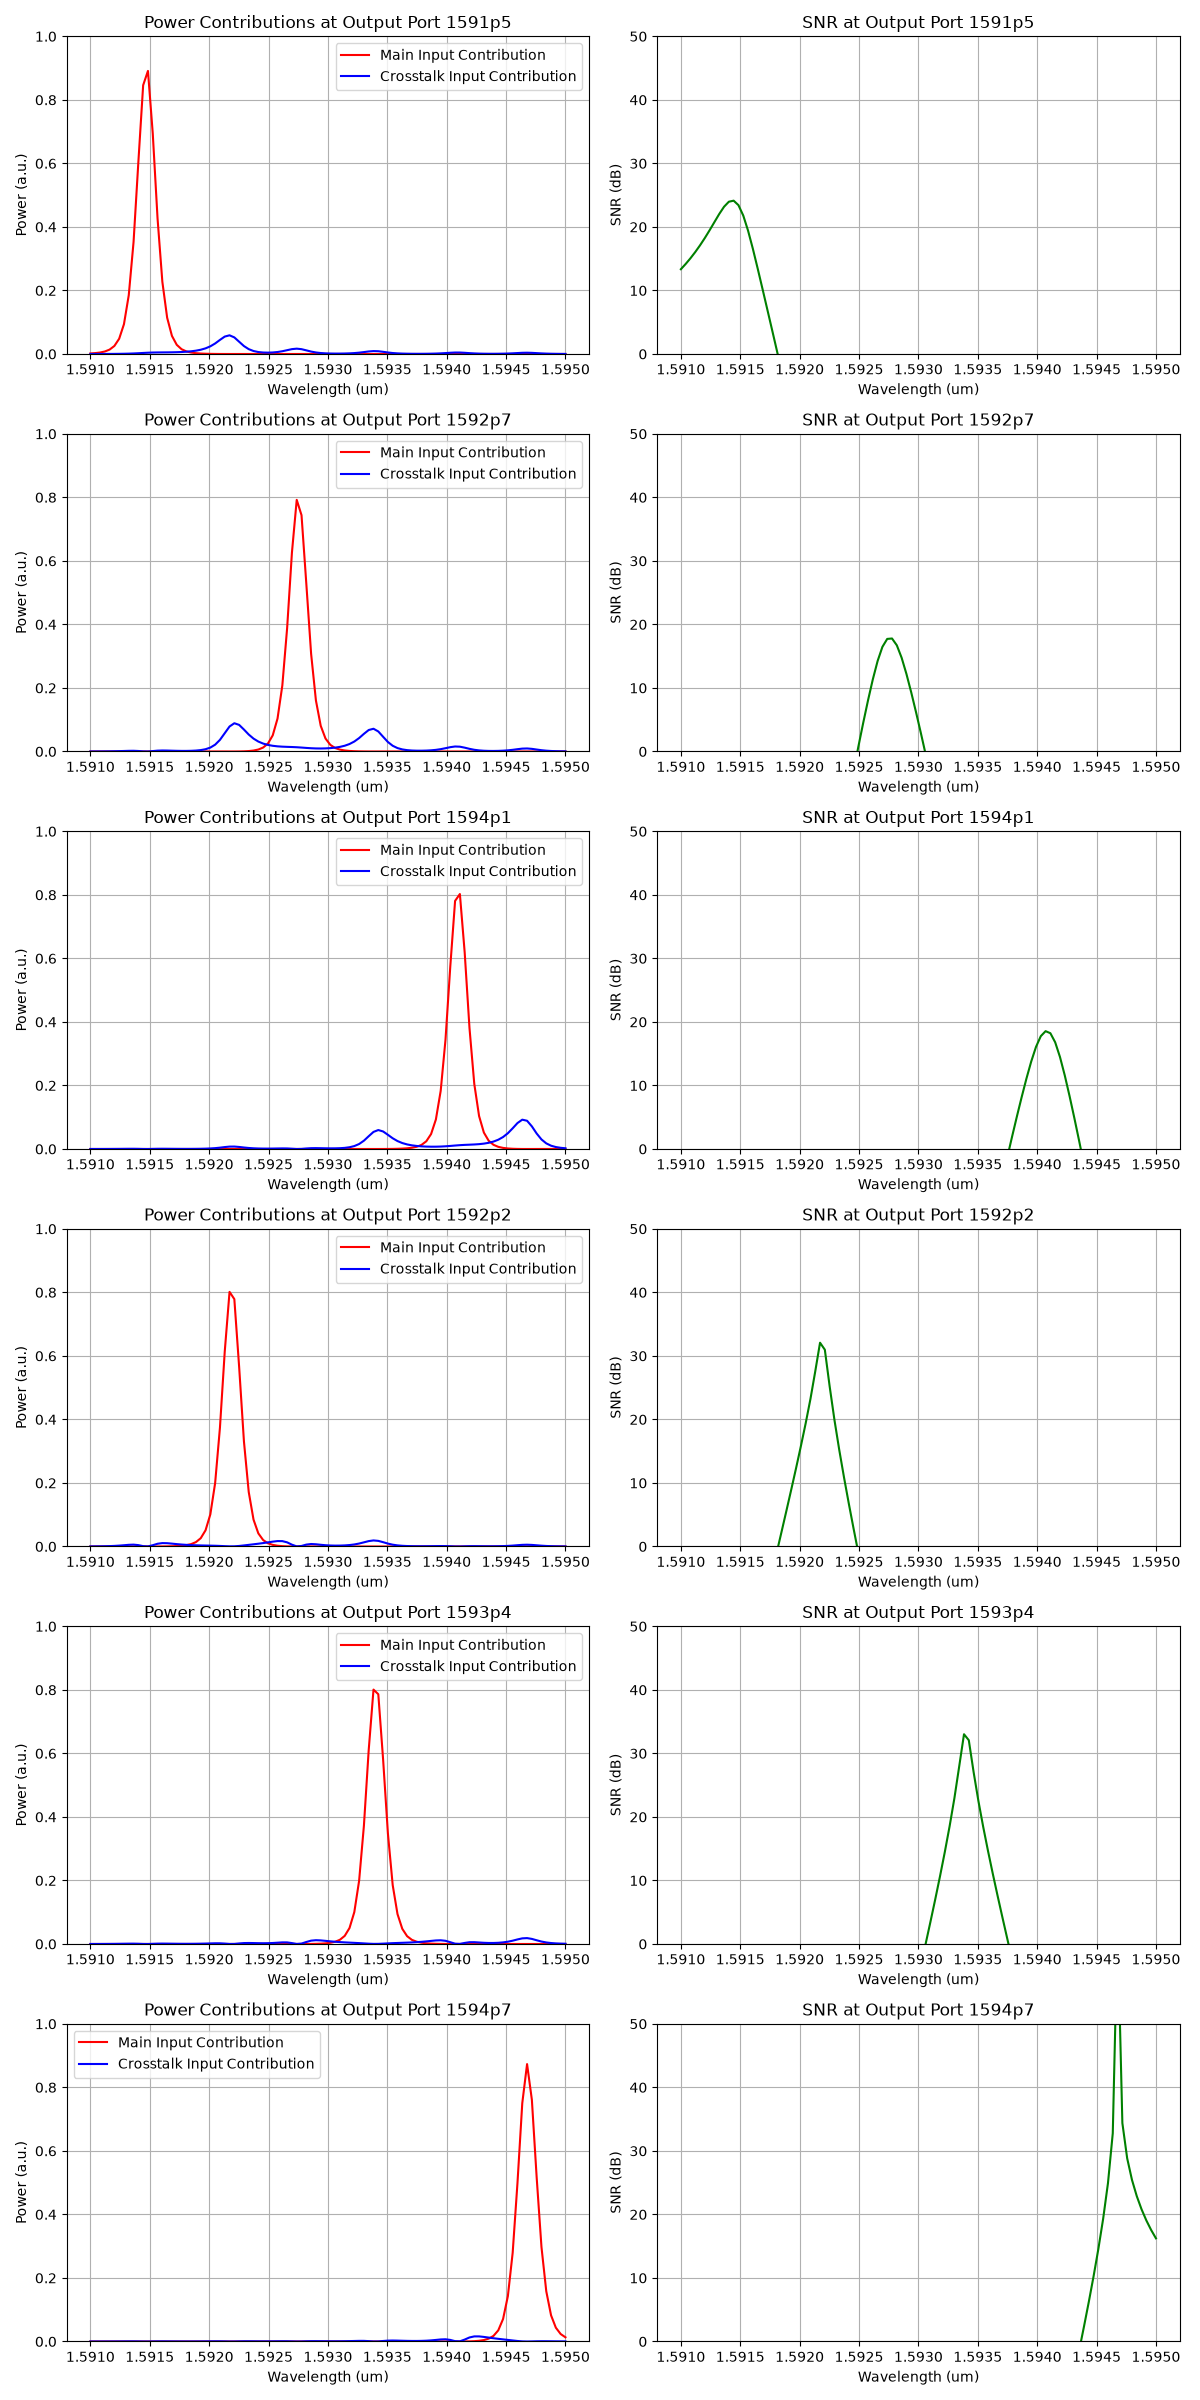

In [119]:
input_ports, output_ports = input_output_ports(wavelengths)
S = circuit(wl=wls, **params)
plot_power_contributions_and_snr(S, wavelengths, input_ports, output_ports)

## Optical to Digital

In [120]:
def compute_digital_outputs(S, wavelengths):
    _, output_ports = input_output_ports(wavelengths)
    digital_outputs = {}
    for i, wl_spec in enumerate(wavelengths):
        main_input_contribution, crosstalk_input_contribution, SNR = compute_power_contributions(S, wl_spec, input_ports, output_ports)
        total_power = main_input_contribution + crosstalk_input_contribution

        # say I apply 1pJ of uniform energy to each input port, then the output has a total power per wavelength as sum from input contributions
        # say I have a detector at output port that triggers IF the sum of total power accross all wavelengths is above a threshold, then if it happens I have a digital 1, else 0
        # say my dectector characteristics are
        # rx_dBm = -20 # is approx 10 uW
        # rx_power = (10 ** (rx_dBm / 10)) / 1000 # in W

        # # So we want to send each port equally 
        # integrate total_power to get a total_energy value
        # does a simple SUM over all wavelengths work?
        # answer: yes, because the total power is already a sum of contributions from all input ports, so summing over wavelengths gives the total energy received at the output port.
        total_energy = jnp.sum(total_power) * (wls[1] - wls[0]) # in a.u. units, but proportional to energy
        # print(f"Output Port {wl_sp
        # ec['wl_label']}: Total Energy = {total_energy:.6f}, SNR = {jnp.mean(SNR):.2f} dB")

        # 0.0002 Joules is 200uJ, which is a lot of energy for a photonic circuit. So we can say that if total_energy > 0.0002, then the detector triggers a digital 1, else 0.
        digital_outputs[wl_spec['wl_label']] = 1 if total_energy > 0.0001 else 0
        # print(f"Output Port {wl_spec['wl_label']}: Digital Output = {digital_outputs[wl_spec['wl_label']]}")
    return digital_outputs

compute_digital_outputs(S, wavelengths)



{'1591p5': 1, '1592p7': 1, '1594p1': 1, '1592p2': 1, '1593p4': 1, '1594p7': 1}

## Digital to Optical

In [121]:
def params_for_modulators(params: dict[str, dict], mrs_in_high: list[str]) -> dict[str, dict]:
    #mrs_in_high = ["1591p5", "1592p7", "1594p1"]
    adjusted_params = {}
    for key, value in params.items():
        adjusted_params[key] = value.copy()
        
        key_is_modulator = key.startswith("mr_mod_")
        if key_is_modulator:
            wl_label = key.split("_")[2]
            if wl_label not in mrs_in_high:
                adjusted_params[key]["radius"] += 1  # Increase radius of modulator to shift resonance away from the laser wavelength
    return adjusted_params

adjusted_params = params_for_modulators(params, ['1592p2', '1593p4'])
S2 = circuit(wl=wls, **adjusted_params)

compute_digital_outputs(S2, wavelengths)

{'1591p5': 0, '1592p7': 0, '1594p1': 0, '1592p2': 1, '1593p4': 1, '1594p7': 0}

In [122]:
# simulation will go as timesteps 0, 1, 2, ..., duration-1,   duration=5
# each timestep, we have 6 digital inputs IN0, IN1, IN2, IN3, IN4, IN5 and 6 digital outputs OUT0, OUT1, OUT2, OUT3, OUT4, OUT5

input_streams = {
    "IN0": [0, 1, 0, 1, 0, 1],
    "IN1": [1, 0, 1, 0, 1, 0],
    "IN2": [0, 0, 1, 1, 0, 0],
    "IN3": [1, 1, 0, 0, 1, 1],
    "IN4": [0, 1, 1, 0, 1, 0],
    "IN5": [1, 0, 0, 1, 0, 1]
}

output_streams = ["OUT0", "OUT1", "OUT2", "OUT3", "OUT4", "OUT5"]

# create "systemcomponents to represent E-O interfaces to extract it's digital signal"
class SystemComponent:
    def __init__(self, name):
        self.name = name
        self.signals = {}

    def evaluate(self, ts: int):
        raise NotImplementedError("Subclasses should implement this method.")
    
class DigitalSignal:
    def __init__(self, name):
        self.name = name
        self.value = 0

    def set_value(self, value):
        self.value = value

    def get_value(self):
        return self.value
    
class OpticalSignal:
    pass

class EOInterface(SystemComponent): # names will be IN0
    def __init__(self, name):
        super().__init__(name)
        self.signals[name] = DigitalSignal(name)
        self.signals[name].set_value(input_streams[name][0])  # initialize with the first value

    def evaluate(self, ts: int):
        # get the value of the digital signal at this timestep
        value = input_streams[self.name][ts]
        self.signals[self.name].set_value(value)
        return value

In [144]:
wavelengths_specs = [
    {
        "wl": 1.59148484848,
        "wl_label": "1591p5",
        "radius": 7.90
    },
    {
        "wl": 1.59273737373,
        "wl_label": "1592p7",
        "radius": 7.70
    },
    {
        "wl": 1.59411111111,
        "wl_label": "1594p1",
        "radius": 7.50
    },
    {
        "wl": 1.59217171717,
        "wl_label": "1592p2",
        "radius": 8.433333333333334
    },
    {
        "wl": 1.59338383838,
        "wl_label": "1593p4",
        "radius": 8.233333333333333
    },
    {
        "wl": 1.59467676767,
        "wl_label": "1594p7",
        "radius": 8.033333333333333
    }
]

class WDMCircuitComponent(SystemComponent):
    def __init__(self, name, eo_interfaces: list[EOInterface]):
        super().__init__(name)
        self.wls = np.linspace(1.591, 1.595, 100)
        self.netlist, self.base_params, self.circuit, self.info = create_wdm_circuit(wavelengths_specs)
        self.input_ports, self.output_ports = input_output_ports(wavelengths_specs)

        self.eo_interfaces = eo_interfaces
        self.eo_wl_mapping = self._get_wl_mapping_for_eo_interfaces(eo_interfaces, wavelengths_specs)
        self.signals = self._create_output_signals(eo_interfaces)
        self.wl_oe_mapping = self._get_oe_mapping_for_wls(self.eo_wl_mapping)

    def _get_wl_mapping_for_eo_interfaces(self, eo_interfaces: list[EOInterface], wavelengths_specs: list[dict]):
        if (len(eo_interfaces) > len(wavelengths_specs)):
            raise ValueError("Number of EO interfaces is greater than the number of wavelengths available.")
        
        mapping = {}
        # we want to map eo_interface name to the corresponding wavelength label
        for i in range(len(eo_interfaces)):
            mapping[eo_interfaces[i].name] = wavelengths_specs[i]['wl_label']

        return mapping
    
    def _get_oe_mapping_for_wls(self, eo_wl_mapping: dict[str, str]):
        # eo_wl_mapping = IN{number} -> wl_label,
        # oe_mapping = wl_label -> OUT{number}
        mapping = {v: k.replace("IN", "OUT") for k, v in eo_wl_mapping.items()}
        return mapping

    def _get_active_modulators(self, eo_interfaces: list[EOInterface], mapping):
        active_modulators = []
        for eo_interface in eo_interfaces:
            if eo_interface.signals[eo_interface.name].get_value() == 1:
                active_modulators.append(mapping[eo_interface.name])
        return active_modulators
    
    def _create_output_signals(self, eo_interfaces: list[EOInterface]):
        output_signals = {}
        for eo_interface in eo_interfaces:
            output_name = eo_interface.name.replace("IN", "OUT")
            output_signals[output_name] = DigitalSignal(output_name)
        return output_signals

    def evaluate(self, ts: int):
        # Update the modulator parameters based on the digital inputs
        mrs_in_high = self._get_active_modulators(self.eo_interfaces, self.eo_wl_mapping)
        new_params = params_for_modulators(self.base_params, mrs_in_high)
        S = self.circuit(wl=self.wls, **new_params)
        digital_outputs = compute_digital_outputs(S, wavelengths_specs)
        # Update the digital output signals based on the computed outputs
        for wl_label, output_value in digital_outputs.items():
            output_name = self.wl_oe_mapping[wl_label]
            self.signals[output_name].set_value(output_value)

In [145]:

# for output_name in output_streams:
#     system_components[output_name] = SystemComponent(output_name)  # Placeholder for output components
# system_components
input_components = [EOInterface(name) for name in input_streams.keys()]
processing_components = [
    WDMCircuitComponent("WDMCircuit", eo_interfaces=input_components)
]
ouput_components = []

system_components = input_components + processing_components + ouput_components

In [147]:
from vcd import VCDWriter


def simulate(system: list[SystemComponent], duration: int, filename: str):

    # for now it is already sorted
    # system = topologically_sort_system(system) # topologically sort the system components based on their signal dependencies to ensure correct evaluation order during simulation

    # for simplicity, we assume that the system is evaluated at discrete time steps and that the signals are updated synchronously at each time step
    with VCDWriter(open(filename, "w"), timescale="1 ns", date="today") as writer:
        # Register all signals in the system with the VCD writer
        signal_to_var = {} # mapping from signal object to VCD variable for writing changes during simulation
        for component in system:
            for signal_name, signal in component.signals.items():
                if isinstance(signal, OpticalSignal):
                    var_type = "real"
                    init_value = signal.get_total_power()
                elif isinstance(signal, DigitalSignal):
                    var_type = "integer"
                    init_value = signal.get_value()
                else:
                    raise ValueError("Unknown signal type")
                var = writer.register_var("Top", signal_name, var_type, init=init_value)
                signal_to_var[signal] = var

        # Simulate the system for the given duration
        for timestamp in range(duration):
            # For simplicity, we assume that the input electrical signals change according to their defined sequence at their specified timestamps
            for component in system:
                component.evaluate(timestamp)

            # After evaluating the system components, we write the current state of all signals to the VCD file
            for signal, var in signal_to_var.items():
                if isinstance(signal, OpticalSignal):
                    value = signal.get_total_power()
                elif isinstance(signal, DigitalSignal):
                    value = signal.get_value()
                else:
                    raise ValueError("Unknown signal type")
                writer.change(var, timestamp, value)

        writer.close()


simulate(system_components, duration=6, filename="test_simulation.vcd")

### Visualize Inputs/Outputs
```
gtkwave test_simulation.vcd
```